# Data 440 Machine Learning Project 1

## The assignment

In Project 1, your goal is to create two different machine learning models of a relationship between variables.  The first model should be based on linear separation, trees, or distance (the early part of the semester) and the second model should be a neural network.  You will then compare the models, discussing training time, development time (how long it takes you to develop each model), and accuracy of predictions.

You can select one of the following data sets to work with:

* Marketing A/B testing ([link](https://github.com/cbrown-clu/class_data/raw/refs/heads/main/data/marketing_AB.csv)), predict the `converted` variable.
* Weather from reporting stations in So Cal ([link](https://github.com/cbrown-clu/class_data/raw/refs/heads/main/data/weather_allstations_cleaned.csv)), predict the `Condition` variable.
* Bank customer churn data ([link](https://github.com/cbrown-clu/class_data/raw/refs/heads/main/data/Bank_Customer_Churn_Prediction.csv)), predict the `churn` variable.
* Movie database ([link](https://github.com/cbrown-clu/class_data/raw/refs/heads/main/data/tmdb_5000_movies.csv)), predict the `popularity` variable.
* A data set of your choosing.  It must have a significant number of rows of data, you must identify the target to predict, it must not be synthesized data, and you must send me the provenance of the data (a link or links) within a week of this project being assigned.

## The deliverables

* The code you use to import and clean your data, and the code you use to create and assess your models.  Your code should be clearly commented and should demonstrate good coding practices.
* A short presentation (5 or fewer minutes) discussing and comparing the two models you create.

## The rubric

* Import, clean, and transform your data.  Clearly identify the target variable.
* Create at least one model (Model 1) predicting the target variable in your data.  Model 1 should be based on our early work this semester with models based on linear separation, trees, and distance.
* Train Model 1.  Tune hyperparameters as needed.
* Assess the quality of Model 1.
* Create a neural network model (Model 2) predicting the target variable in your data.
* Train Model 2.  Engineer layers and activation functions as needed.
* Assess the quality of Model 2.
* Provide documented code for your data import, Model 1, and Model 2.
* Present on the two models you created.  Compare the development time (how long it took you to create them), training time, and accuracy of their predictions.
* Your presentation should be 5 or fewer minutes in length, use plots and diagrams as necessary, and should use appropriate terminology for the subject area.

Each bullet point in the rubric is graded on a 0-1-2 point scale and there are a total of 20 points available on this project.

# Model 1

## Import and Clean Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
adult_1 = pd.read_csv('https://github.com/cari-lin/class_data/raw/refs/heads/main/adult.data', header=None)
adult_2 = pd.read_csv('https://github.com/cari-lin/class_data/raw/refs/heads/main/adult.test', skiprows=1, header=None)

In [ ]:
adult_m1 = pd.concat([adult_1, adult_2])
adult_m1.columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
display(adult_m1.shape)
display(adult_m1.head())

(48842, 15)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
adult_m1 = adult_m1.replace(' ?', np.nan)
adult_m1 = adult_m1.dropna(subset=['income']) # Drop rows with NaN in the 'income' column
adult_m1 = adult_m1.dropna() # Drop remaining rows with NaN in any column
adult_m1 = adult_m1.reset_index(drop=True) # Reset index after cleaning

display(adult_m1.head())
print(f"Shape after cleaning: {adult_m1.shape}")

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Shape after cleaning: (45222, 15)


In [ ]:
adult_m1.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
adult_m1.shape

(45222, 15)

## Linear Regression

Linear Regression Accuracy: 0.852
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90     10193
        >50K       0.75      0.61      0.67      3374

    accuracy                           0.85     13567
   macro avg       0.81      0.77      0.79     13567
weighted avg       0.85      0.85      0.85     13567



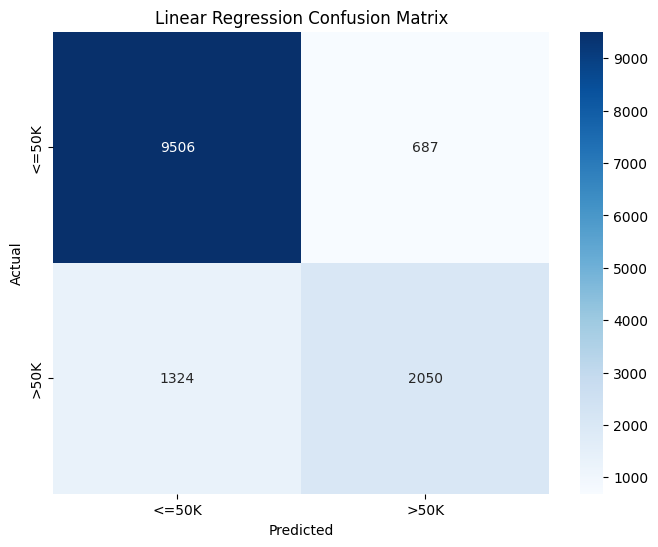

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Clean the target variable
adult_m1['income'] = adult_m1['income'].str.strip() # Remove leading/trailing whitespace
adult_m1['income'] = adult_m1['income'].replace(['<=50K.', '>50K.'], ['<=50K', '>50K']) # Consolidate variations

# One-hot encode categorical features
X = pd.get_dummies(adult_m1.drop('income', axis=1))
y = adult_m1['income']

# Encode the target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
linear_model = LogisticRegression(max_iter=1000) # Using Logistic Regression for binary classification
linear_model.fit(X_train_scaled, y_train)
y_pred_lr = linear_model.predict(X_test_scaled)

# Evaluate the model
acc_lr = accuracy_score(y_test, y_pred_lr)
print("Linear Regression Accuracy:", round(acc_lr, 3))
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Linear Regression Confusion Matrix')
plt.show()

## Decision Tree Classifier

Decision Tree Accuracy: 0.808
              precision    recall  f1-score   support

       <=50K       0.88      0.87      0.87     10193
        >50K       0.61      0.63      0.62      3374

    accuracy                           0.81     13567
   macro avg       0.74      0.75      0.74     13567
weighted avg       0.81      0.81      0.81     13567



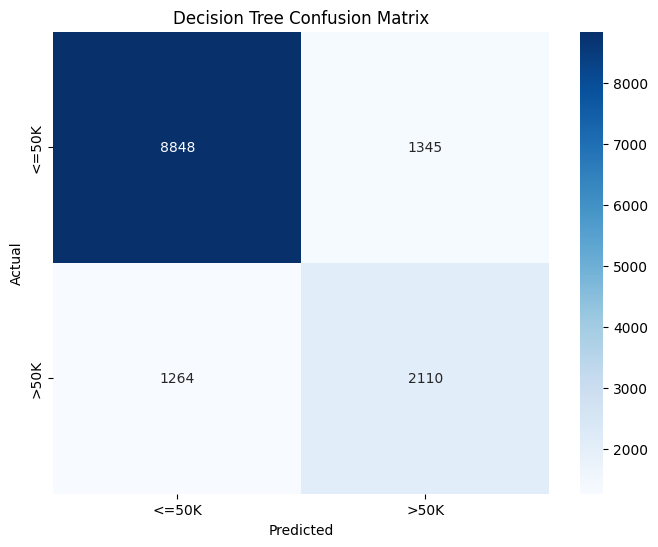

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd # Import pandas here in case the user runs this cell independently

# Assuming 'adult_m1' is already loaded and cleaned as in previous cells

# One-hot encode categorical features
X = pd.get_dummies(adult_m1.drop('income', axis=1))
y = adult_m1['income']

# Encode the target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split (using the same split as the linear model for comparison)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# Decision Tree Model
dt_model = DecisionTreeClassifier(random_state=42) # You can tune hyperparameters later if needed
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# Evaluate the model
acc_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", round(acc_dt, 3))
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')
plt.show()

## K - Nearest Neighbor Classifier

Best k: 15 with Accuracy: 0.83


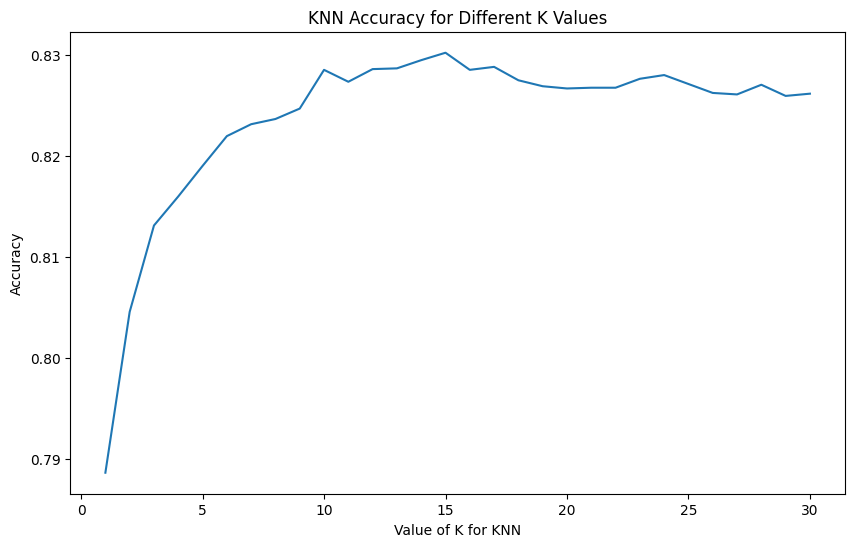


Classification Report for Best KNN Model:
              precision    recall  f1-score   support

       <=50K       0.86      0.92      0.89     10193
        >50K       0.70      0.56      0.62      3374

    accuracy                           0.83     13567
   macro avg       0.78      0.74      0.76     13567
weighted avg       0.82      0.83      0.82     13567



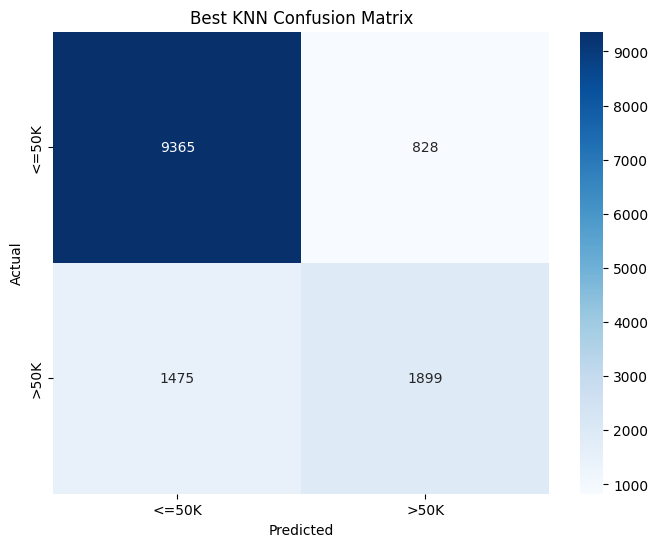

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming 'adult_m1' is already loaded and cleaned as in previous cells

# One-hot encode categorical features
X = pd.get_dummies(adult_m1.drop('income', axis=1))
y = adult_m1['income']

# Encode the target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# Scale the features (KNN is sensitive to feature scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Find the best k for KNN
k_range = range(1, 31) # Test k from 1 to 30
scores = {}
best_k = -1
best_acc = -1

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_knn = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_knn)
    scores[k] = acc
    if acc > best_acc:
        best_acc = acc
        best_k = k

print(f"Best k: {best_k} with Accuracy: {round(best_acc, 3)}")

# Optional: Plot k vs accuracy
plt.figure(figsize=(10, 6))
plt.plot(k_range, list(scores.values()))
plt.xlabel("Value of K for KNN")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K Values")
plt.show()

# Evaluate the best KNN model
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred_knn_best = knn_best.predict(X_test_scaled)

print("\nClassification Report for Best KNN Model:")
print(classification_report(y_test, y_pred_knn_best, target_names=le.classes_))

# Confusion Matrix for best KNN model
cm_knn = confusion_matrix(y_test, y_pred_knn_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Best KNN Confusion Matrix')
plt.show()

## Random Forest Classifier

Random Forest Accuracy: 0.852
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90     10193
        >50K       0.74      0.63      0.68      3374

    accuracy                           0.85     13567
   macro avg       0.81      0.78      0.79     13567
weighted avg       0.85      0.85      0.85     13567



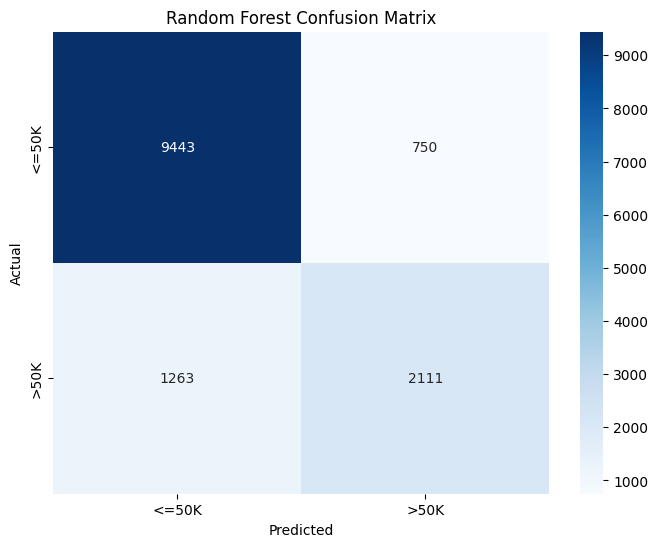

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'adult_m1' is already loaded and cleaned as in previous cells

# One-hot encode categorical features
X = pd.get_dummies(adult_m1.drop('income', axis=1))
y = adult_m1['income']

# Encode the target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split (using the same split as the previous models for comparison)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# Random Forest Model
rf_model = RandomForestClassifier(random_state=42) # You can tune hyperparameters later
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", round(acc_rf, 3))
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

## XGBoost Classification

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [21:49:43] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.87
              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.92     10193
        >50K       0.78      0.67      0.72      3374

    accuracy                           0.87     13567
   macro avg       0.84      0.80      0.82     13567
weighted avg       0.87      0.87      0.87     13567



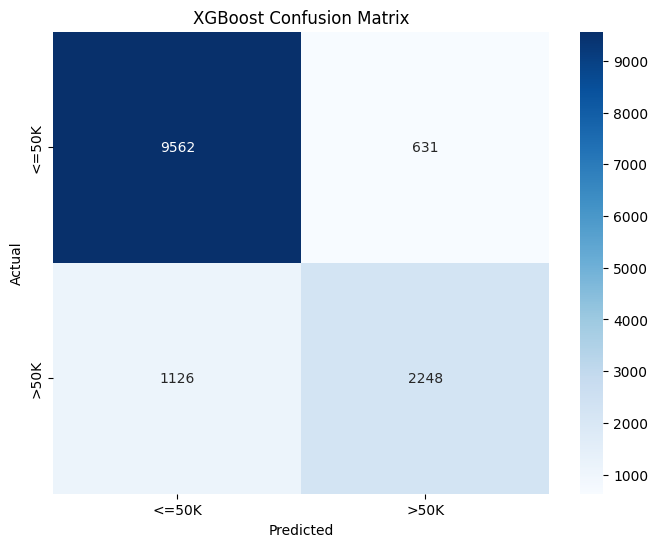

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'adult_m1' is already loaded and cleaned as in previous cells

# One-hot encode categorical features
X = pd.get_dummies(adult_m1.drop('income', axis=1))
y = adult_m1['income']

# Encode the target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split (using the same split as the previous models for comparison)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# XGBoost Model
# You might need to install xgboost: !pip install xgboost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42) # Added parameters to avoid warning
xgb_model.fit(X_train, y_train) # Corrected variable name to y_train

y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Accuracy:", round(acc_xgb, 3))
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix')
plt.show()

## Comparing all the models

/tmp/ipython-input-1628621944.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracy_scores, palette='viridis')


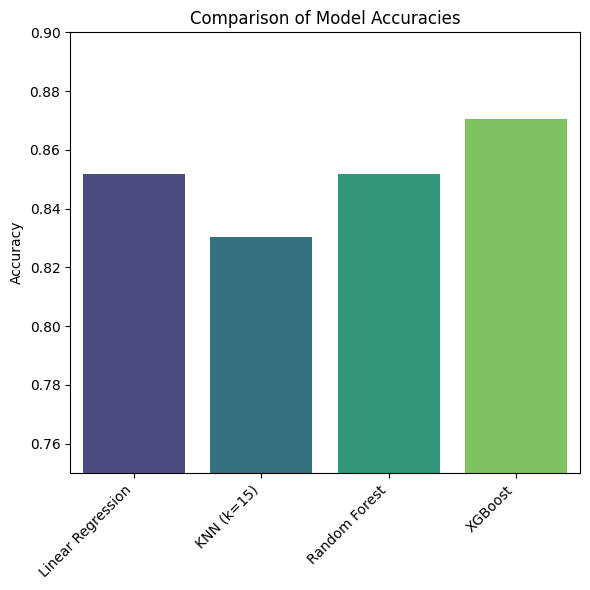

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming the accuracy scores from previous cells are available:
# acc_lr (Linear Regression)
# acc_dt (Decision Tree)
# best_acc (KNN with best k)
# acc_rf (Random Forest)
# acc_xgb (XGBoost)

model_names = ['Linear Regression', f'KNN (k={best_k})', 'Random Forest', 'XGBoost']
accuracy_scores = [acc_lr, best_acc, acc_rf, acc_xgb]

plt.figure(figsize=(6, 6)) # Adjusted figure size here
sns.barplot(x=model_names, y=accuracy_scores, palette='viridis')
plt.ylim(0.75, 0.9) # Adjust y-limit to focus on the range of accuracies
plt.ylabel('Accuracy')
plt.title('Comparison of Model Accuracies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Assuming the accuracy scores from previous cells are available:
# acc_lr (Linear Regression)
# best_acc (KNN with best k)
# acc_rf (Random Forest)
# acc_xgb (XGBoost)

print(f"Model Accuracies:")
print(f"Linear Regression: {round(acc_lr, 3)}")
print(f"KNN (k={best_k}): {round(best_acc, 3)}")
print(f"Random Forest: {round(acc_rf, 3)}")
print(f"XGBoost: {round(acc_xgb, 3)}")

Model Accuracies:
Linear Regression: 0.852
KNN (k=15): 0.83
Random Forest: 0.852
XGBoost: 0.87
